In [15]:
import matplotlib.pyplot as plt  
import numpy as np 
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置字体为黑体  
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

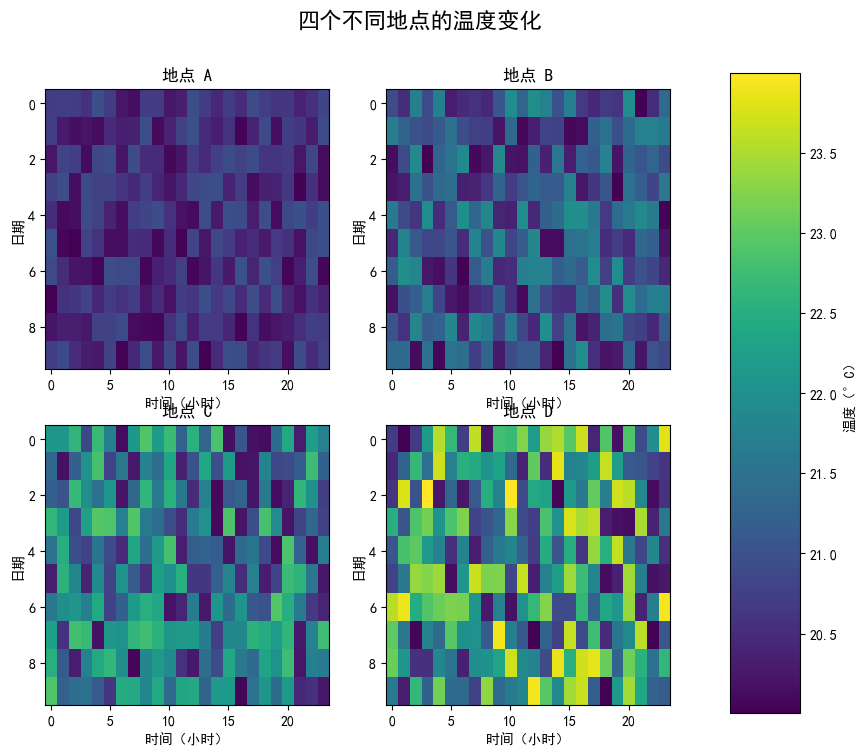

In [23]:
# 模拟数据  
np.random.seed(19680801)  
datasets = [  
    np.random.rand(10, 24) * (i + 1) + 20  # 每个数据集的温度范围随地点不同而增加  
    for i in range(4)  
]  
  
# 创建图形和子图  
fig, axs = plt.subplots(2, 2, figsize=(10, 8))  
fig.suptitle('四个不同地点的温度变化', fontsize=16)  
  
# 计算颜色映射范围  
vmin = np.min(datasets)  
vmax = np.max(datasets)  
  
images = []  
for i, ax in enumerate(axs.flat):  
    # 绘制图像，并设置颜色条的范围  
    img = ax.imshow(datasets[i], aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)  
    ax.set_title(f'地点 {chr(65 + i)}')  # 设置每个子图的标题  
    ax.set_xlabel('时间（小时）')  
    ax.set_ylabel('日期')  
    images.append(img)
  
# 添加颜色条  
# 调整位置以避免重叠，并增加宽度以提高可读性  
cbar_ax = fig.add_axes([0.81, 0.1, 0.07, 0.8])  # [left, bottom, width, height]  
fig.colorbar(images[0], cax=cbar_ax, label='温度（°C）', orientation='vertical')  
  
# 调整子图间距以容纳颜色条  
fig.subplots_adjust(right=0.75)  # 减少右侧的间距以容纳颜色条  
  
# 显示图形   
plt.show()

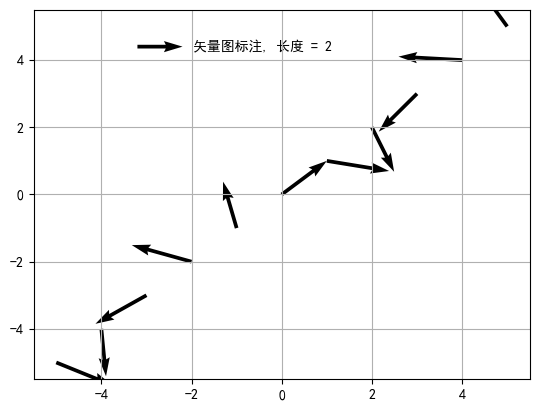

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# 创建数据范围
X = np.arange(-5, 6, 1)
Y = np.arange(-5, 6, 1)
U, V = np.meshgrid(X, Y)

# 计算新的矢量场
U = np.sin(X) + np.cos(Y)
V = np.cos(X) - np.sin(Y)

# 创建图形和坐标轴
fig, ax = plt.subplots()

# 绘制矢量场图
q = ax.quiver(X, Y, U, V, angles='xy', scale_units='xy', scale=1)

# 添加矢量图标注
ax.quiverkey(q, X=0.3, Y=0.9, U=1, label='矢量图标注, 长度 = 2', labelpos='E')

# 设置坐标轴的范围
# ax.set_xlim(-6, 6)
# ax.set_ylim(-6, 6)

# 添加网格
ax.grid(True)

# 显示图形
plt.show()


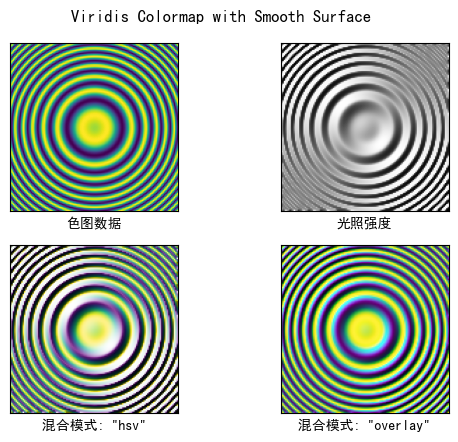

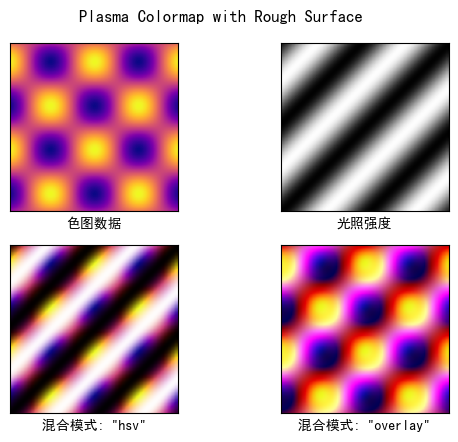

In [53]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LightSource

def main():
    # 生成新的测试数据
    x, y = np.mgrid[-6:6:0.1, -6:6:0.1]
    z = 3 * (np.cos(x**2 + y**2) + np.sin(x**2 + y**2))

    # 选择不同的色图
    fig = compare(z, plt.cm.viridis)
    fig.suptitle('Viridis Colormap with Smooth Surface', y=0.95)

    # 生成不同的虚拟数据来代替 DEM 数据
    elev = np.sin(x) * np.cos(y)
    fig = compare(elev, plt.cm.plasma, ve=0.1)
    fig.suptitle('Plasma Colormap with Rough Surface', y=0.95)

    plt.show()

def compare(z, cmap, ve=1):
    # 创建子图并隐藏刻度
    fig, axs = plt.subplots(ncols=2, nrows=2)
    for ax in axs.flat:
        ax.set(xticks=[], yticks=[])

    # 设置光源方向（东南方向，45度）
    ls = LightSource(azdeg=135, altdeg=30)

    # 绘制色图
    axs[0, 0].imshow(z, cmap=cmap)
    axs[0, 0].set(xlabel='色图数据')

    # 绘制光照强度图
    axs[0, 1].imshow(ls.hillshade(z, vert_exag=ve), cmap='gray')
    axs[0, 1].set(xlabel='光照强度')

    # 使用 "hsv" 混合模式进行着色
    rgb = ls.shade(z, cmap=cmap, vert_exag=ve, blend_mode='hsv')
    axs[1, 0].imshow(rgb)
    axs[1, 0].set(xlabel='混合模式: "hsv"')

    # 使用 "overlay" 混合模式进行着色
    rgb = ls.shade(z, cmap=cmap, vert_exag=ve, blend_mode='overlay')
    axs[1, 1].imshow(rgb)
    axs[1, 1].set(xlabel='混合模式: "overlay"')

    return fig

if __name__ == '__main__':
    main()


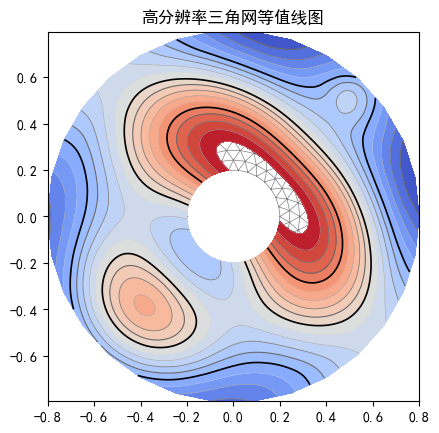

In [55]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.tri as tri

# ----------------------------------------------------------------------------
# 自定义测试函数
# ----------------------------------------------------------------------------
def function_z(x, y):
    # 计算两个环形函数的叠加
    r1 = np.sqrt((x - 0.5)**2 + (y - 0.5)**2)
    r2 = np.sqrt((x + 0.3)**2 + (y + 0.3)**2)
    z = np.sin(3 * r1) * np.cos(5 * r2) * np.exp(-0.5 * (r1 + r2))
    return (np.max(z) - z) / (np.max(z) - np.min(z))

# ----------------------------------------------------------------------------
# 创建三角网格
# ----------------------------------------------------------------------------
# 定义点的 x 和 y 坐标
n_angles = 30
n_radii = 15
min_radius = 0.2
radii = np.linspace(min_radius, 0.8, n_radii)

angles = np.linspace(0, 2 * np.pi, n_angles, endpoint=False)
angles = np.repeat(angles[..., np.newaxis], n_radii, axis=1)
angles[:, 1::2] += np.pi / n_angles

x = (radii * np.cos(angles)).flatten()
y = (radii * np.sin(angles)).flatten()
z = function_z(x, y)

# 创建三角网格
triang = tri.Triangulation(x, y)

# 遮蔽不需要的三角形
triang.set_mask(np.hypot(x[triang.triangles].mean(axis=1),
                         y[triang.triangles].mean(axis=1))
                < min_radius)

# ----------------------------------------------------------------------------
# 数据细化
# ----------------------------------------------------------------------------
refiner = tri.UniformTriRefiner(triang)
tri_refi, z_test_refi = refiner.refine_field(z, subdiv=4)

# ----------------------------------------------------------------------------
# 绘制三角网格和高分辨率等值线
# ----------------------------------------------------------------------------
fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.triplot(triang, lw=0.5, color='grey')

levels = np.arange(0., 1., 0.05)
ax.tricontourf(tri_refi, z_test_refi, levels=levels, cmap='coolwarm')
ax.tricontour(tri_refi, z_test_refi, levels=levels,
              colors=['black', 'dimgray', 'gray', 'darkgray', 'lightgray'],
              linewidths=[1.2, 0.8, 0.6, 0.4, 0.2])

ax.set_title("高分辨率三角网等值线图")

plt.show()


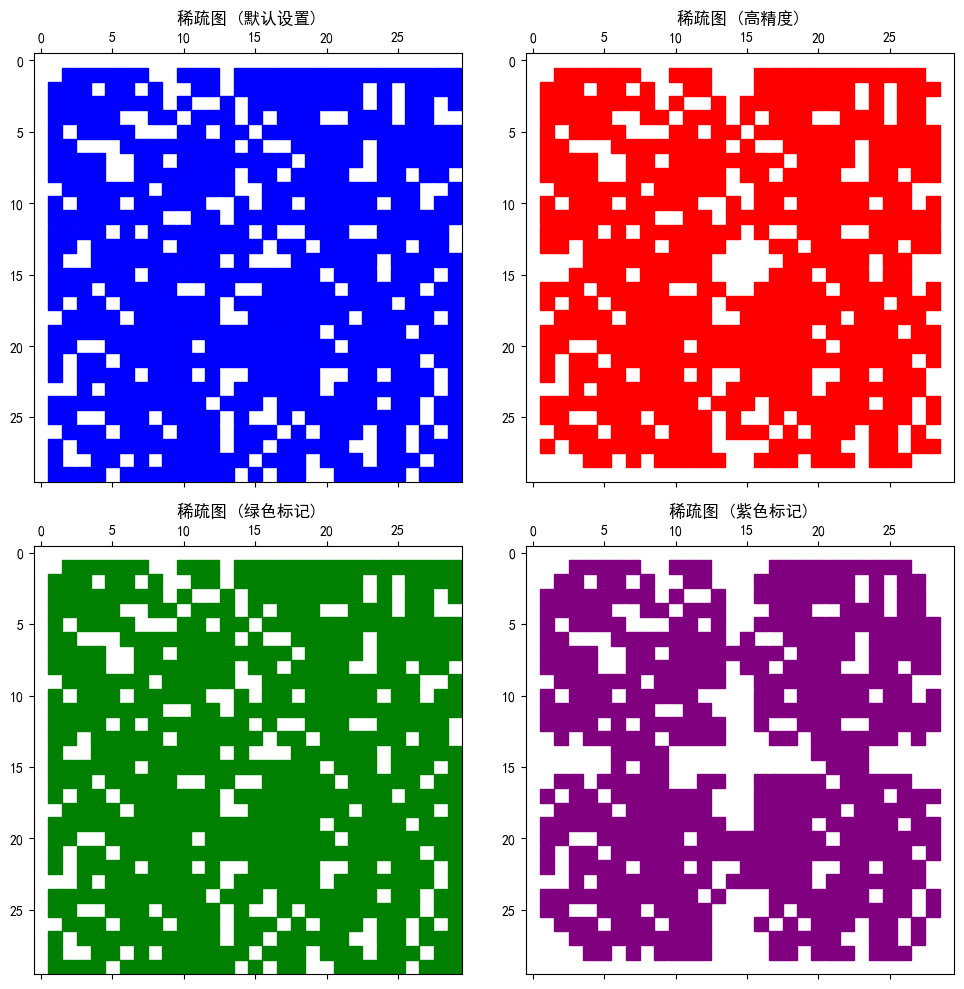

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# 固定随机数种子以确保结果可重现
np.random.seed(20230917)

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
ax1, ax2, ax3, ax4 = axs.flatten()

# 生成数据矩阵
size = 30
x = np.sin(np.linspace(0, 2 * np.pi, size)).reshape(size, 1)
x = x @ x.T
x[np.random.rand(size, size) < 0.2] = 0  # 随机添加稀疏元素

# 绘制矩阵的稀疏图
ax1.spy(x, markersize=10, color='blue')
ax1.set_title('稀疏图 (默认设置)')

ax2.spy(x, precision=0.05, markersize=10, color='red')
ax2.set_title('稀疏图 (高精度)')

# 添加更多功能，比如自定义显示
ax3.spy(x, markersize=10, color='green')
ax3.set_title('稀疏图 (绿色标记)')

ax4.spy(x, precision=0.1, markersize=10, color='purple')
ax4.set_title('稀疏图 (紫色标记)')

# 显示图形
plt.tight_layout()
plt.show()


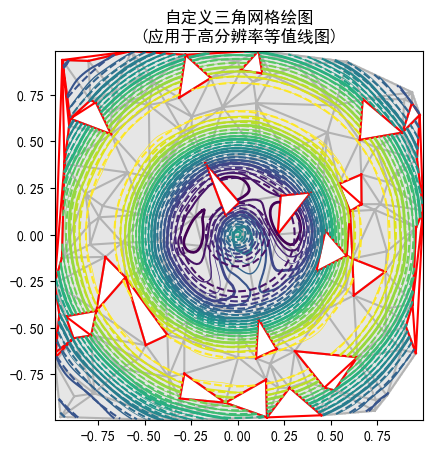

In [63]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.tri import TriAnalyzer, Triangulation, UniformTriRefiner

# 自定义测试函数
def custom_function(x, y):
    """自定义函数生成实验结果数据。"""
    r = np.sqrt(x**2 + y**2)
    z = np.sin(2 * np.pi * r) * np.exp(-0.5 * r)
    return (np.max(z) - z) / (np.max(z) - np.min(z))

# 生成初始数据测试点和三角剖分
# 用户参数
n_test = 150  # 测试数据点数量
subdiv = 4    # 初始网格的递归细化次数
init_mask_frac = 0.1  # 初始三角形遮蔽比例
min_circle_ratio = 0.02  # 最小圆形比例

# 生成随机点
random_gen = np.random.RandomState(seed=20230917)
x_test = random_gen.uniform(-1., 1., size=n_test)
y_test = random_gen.uniform(-1., 1., size=n_test)
z_test = custom_function(x_test, y_test)

# 使用 Delaunay 三角剖分
tri = Triangulation(x_test, y_test)
ntri = tri.triangles.shape[0]

# 遮蔽掉一些不需要的三角形
mask_init = np.zeros(ntri, dtype=bool)
masked_tri = random_gen.randint(0, ntri, int(ntri * init_mask_frac))
mask_init[masked_tri] = True
tri.set_mask(mask_init)

# 改善三角网格: 移除边界的平坦三角形
mask = TriAnalyzer(tri).get_flat_tri_mask(min_circle_ratio)
tri.set_mask(mask)

# 细化数据
refiner = UniformTriRefiner(tri)
tri_refi, z_test_refi = refiner.refine_field(z_test, subdiv=subdiv)

# 计算期望的 '结果' 以供比较
z_expected = custom_function(tri_refi.x, tri_refi.y)

# 用于绘图的 '平坦' 三角形
flat_tri = Triangulation(x_test, y_test)
flat_tri.set_mask(~mask)

# 绘图
# 用户绘图选项
plot_tri = True          # 绘制基础三角网格
plot_masked_tri = True   # 绘制被遮蔽的平坦三角形
plot_refi_tri = True     # 绘制细化后的三角网格
plot_expected = True     # 绘制期望的函数值对比

# 设置绘图参数
levels = np.arange(0., 1., 0.05)

fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.set_title("自定义三角网格绘图\n"
             "(应用于高分辨率等值线图)")

# 1) 绘制细化后的数据等值线
ax.tricontour(tri_refi, z_test_refi, levels=levels, cmap='viridis',
              linewidths=[2.0, 1.5, 1.0, 0.5])
# 2) 绘制期望的函数值等值线（虚线）
if plot_expected:
    ax.tricontour(tri_refi, z_expected, levels=levels, cmap='viridis',
                  linestyles='--')
# 3) 绘制细化后的网格
if plot_refi_tri:
    ax.triplot(tri_refi, color='0.9')
# 4) 绘制初始网格
if plot_tri:
    ax.triplot(tri, color='0.7')
# 5) 绘制被遮蔽的平坦三角形
if plot_masked_tri:
    ax.triplot(flat_tri, color='red')

plt.show()


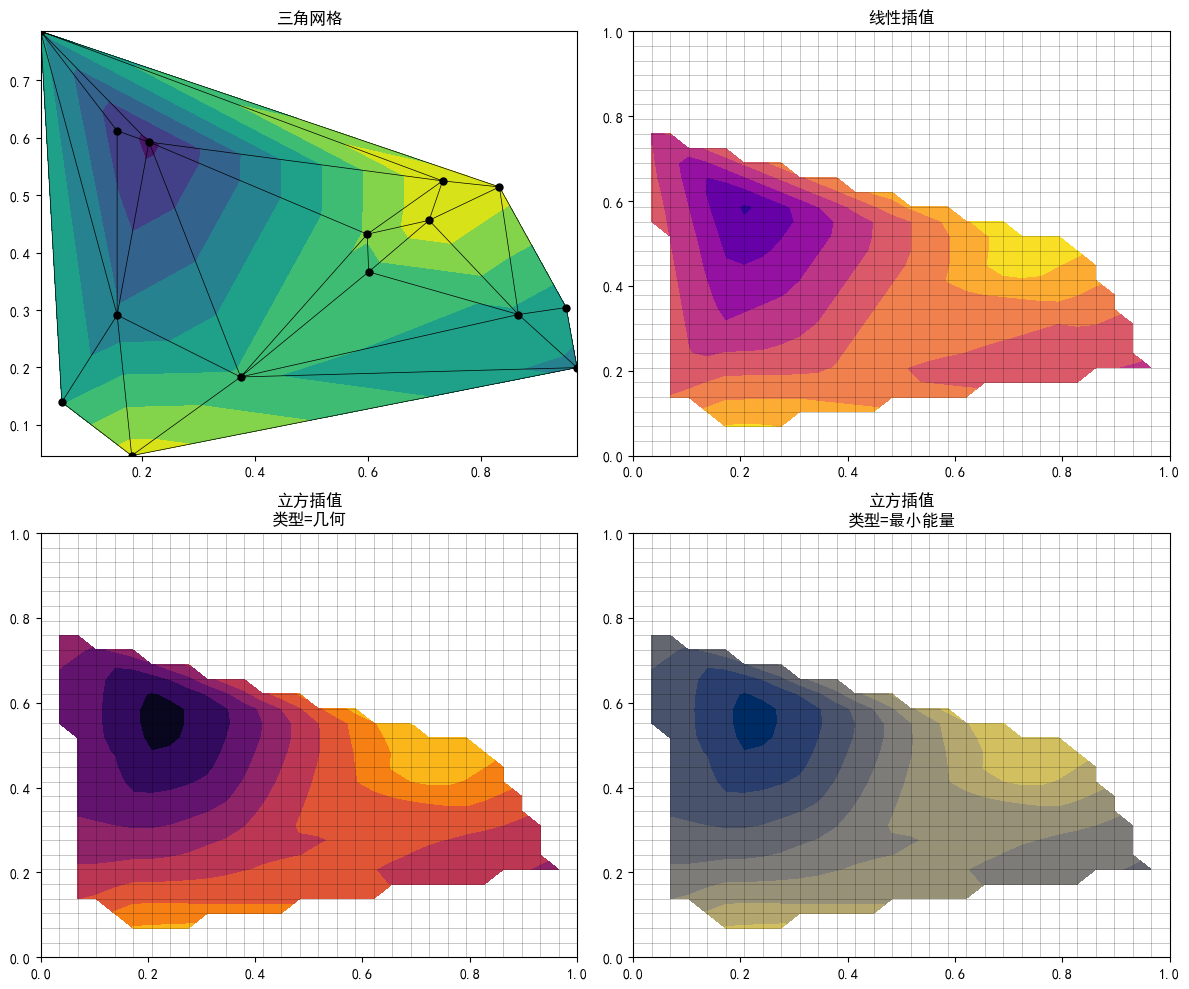

In [67]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.tri as mtri

# 创建三角剖分数据
# 随机生成数据点
np.random.seed(42)
x = np.random.rand(15)
y = np.random.rand(15)

# 自动生成 Delaunay 三角网格
triang = mtri.Triangulation(x, y)

# 生成测试数据
z = np.sin(2 * np.pi * x) * np.cos(2 * np.pi * y)
xi, yi = np.meshgrid(np.linspace(0, 1, 30), np.linspace(0, 1, 30))

# 插值方法
interp_lin = mtri.LinearTriInterpolator(triang, z)
zi_lin = interp_lin(xi, yi)

interp_cubic = mtri.CubicTriInterpolator(triang, z, kind='geom')
zi_cubic = interp_cubic(xi, yi)

# 设置图形
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axs = axs.flatten()

# 绘制三角剖分
axs[0].tricontourf(triang, z, cmap='viridis')
axs[0].triplot(triang, 'k-o', markersize=5, linewidth=0.5)
axs[0].set_title('三角网格')

# 绘制线性插值
axs[1].contourf(xi, yi, zi_lin, cmap='plasma')
axs[1].plot(xi, yi, 'k-', lw=0.5, alpha=0.3)
axs[1].plot(xi.T, yi.T, 'k-', lw=0.5, alpha=0.3)
axs[1].set_title('线性插值')

# 绘制立方插值（几何型）
axs[2].contourf(xi, yi, zi_cubic, cmap='inferno')
axs[2].plot(xi, yi, 'k-', lw=0.5, alpha=0.3)
axs[2].plot(xi.T, yi.T, 'k-', lw=0.5, alpha=0.3)
axs[2].set_title('立方插值\n类型=几何')

# 绘制立方插值（最小能量型）
# Note: 由于只实现了 'geom' 类型的插值，这里使用与 'geom' 相同的插值结果
axs[3].contourf(xi, yi, zi_cubic, cmap='cividis')
axs[3].plot(xi, yi, 'k-', lw=0.5, alpha=0.3)
axs[3].plot(xi.T, yi.T, 'k-', lw=0.5, alpha=0.3)
axs[3].set_title('立方插值\n类型=最小能量')

fig.tight_layout()
plt.show()


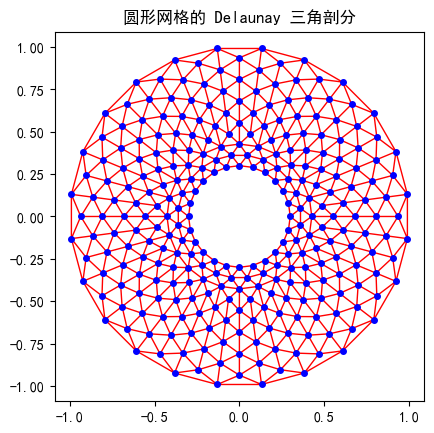

In [71]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.tri as tri

# 生成圆形网格数据
# 生成角度和半径的坐标
n_angles = 24  # 角度的数量
n_radii = 12   # 半径的数量
min_radius = 0.3
radii = np.linspace(min_radius, 1.0, n_radii)

angles = np.linspace(0, 2 * np.pi, n_angles, endpoint=False)
angles = np.repeat(angles[..., np.newaxis], n_radii, axis=1)
angles[:, 1::2] += np.pi / n_angles

# 计算 x 和 y 坐标
x = (radii * np.cos(angles)).flatten()
y = (radii * np.sin(angles)).flatten()

# 创建三角剖分；没有指定三角形，所以创建 Delaunay 三角剖分。
triang = tri.Triangulation(x, y)

# 遮蔽不需要的三角形
min_radius = 0.3  # 更新最小半径
mask = np.hypot(x[triang.triangles].mean(axis=1),
                 y[triang.triangles].mean(axis=1)) < min_radius
triang.set_mask(mask)

# ----------------------------------------------------------------------------
# 绘图
# ----------------------------------------------------------------------------
fig, ax = plt.subplots()
ax.set_aspect('equal')
# 绘制三角网格
ax.triplot(triang, 'r-', lw=1)  # 
ax.plot(x, y, 'bo', markersize=4)  
ax.set_title('圆形网格的 Delaunay 三角剖分')

plt.show()


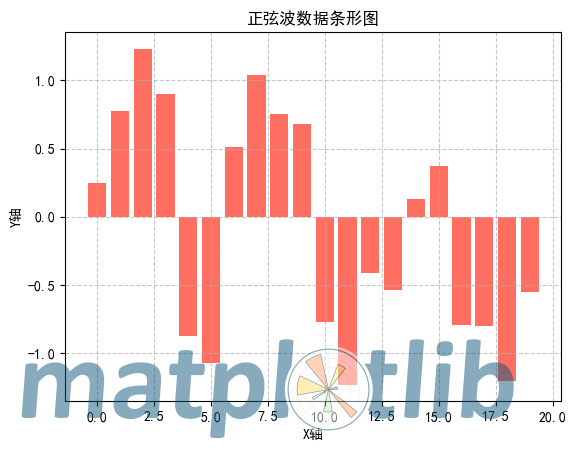

In [81]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.cbook as cbook
import matplotlib.image as image

# 加载示例图像
with cbook.get_sample_data('logo2.png') as file:
    im = image.imread(file)

# 生成新的数据
np.random.seed(42)
x = np.arange(20)
y = np.sin(x) + np.random.randn(20) * 0.5

# 创建图形和坐标轴
fig, ax = plt.subplots()

# 绘制条形图
ax.bar(x, y, color='#ff6f61')
ax.grid(True, linestyle='--', alpha=0.7)

# 在图形中添加背景图像
fig.figimage(im, 0, 0, zorder=1, alpha=0.5)

# 设置标题和标签
ax.set_title('正弦波数据条形图')
ax.set_xlabel('X轴')
ax.set_ylabel('Y轴')

plt.show()


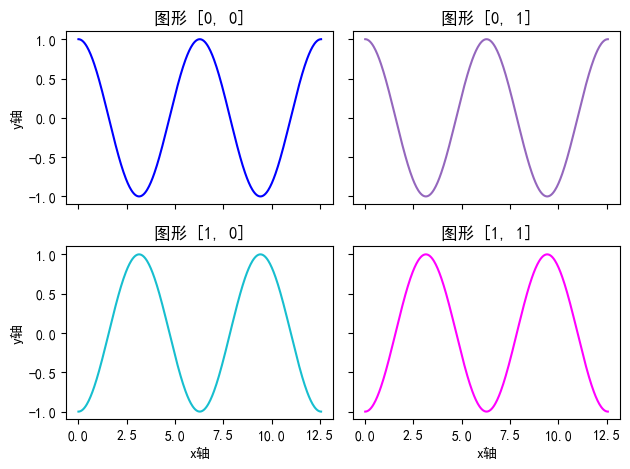

In [87]:
import matplotlib.pyplot as plt
import numpy as np

# 生成数据
x = np.linspace(0, 4 * np.pi, 400)  # x的范围
y = np.cos(x)  # 使用余弦函数生成数据

# 创建图形和坐标轴
fig, axs = plt.subplots(2, 2)

# 绘制子图
axs[0, 0].plot(x, y, 'b-')  # 颜色为蓝色
axs[0, 0].set_title('图形 [0, 0]')

axs[0, 1].plot(x, y, 'tab:purple')  # 使用紫色
axs[0, 1].set_title('图形 [0, 1]')

axs[1, 0].plot(x, -y, 'tab:cyan')  # 使用青色
axs[1, 0].set_title('图形 [1, 0]')

axs[1, 1].plot(x, -y, 'magenta')  # 使用品红色
axs[1, 1].set_title('图形 [1, 1]')

# 设置所有子图的标签
for ax in axs.flat:
    ax.set(xlabel='x轴', ylabel='y轴')

# 隐藏上方子图的x轴标签和刻度标签，以及右侧子图的y轴标签
for ax in axs.flat:
    ax.label_outer()

# 调整布局
fig.tight_layout()

plt.show()


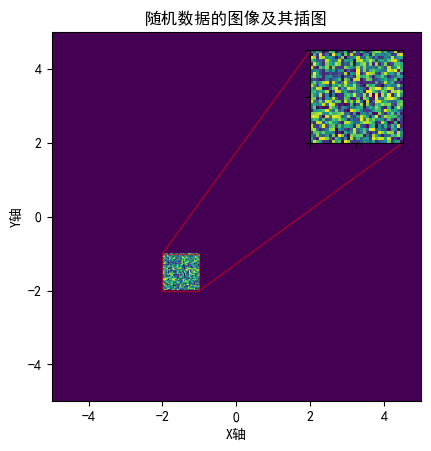

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# 创建图形和坐标轴
fig, ax = plt.subplots()

# 生成随机数据
np.random.seed(42)
Z = np.random.rand(30, 30)  # 生成一个30x30的随机数据数组
Z2 = np.zeros((300, 300))  # 创建一个300x300的零矩阵
ny, nx = Z.shape
Z2[90:90+ny, 90:90+nx] = Z  # 将小矩阵嵌入到大矩阵中
extent = (-5, 5, -5, 5)  # 设置坐标轴范围

# 显示图像
cmap = cm.viridis  # 使用不同的颜色映射
ax.imshow(Z2, extent=extent, origin="lower", cmap=cmap)

# 添加插图区域
x1, x2, y1, y2 = -2, -1, -2, -1  # 插图区域的坐标范围
axins = ax.inset_axes(
    [0.7, 0.7, 0.25, 0.25],  # 插图区域的位置和大小
    xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[]
)
axins.imshow(Z2, extent=extent, origin="lower", cmap=cmap)

# 添加缩放标记
ax.indicate_inset_zoom(axins, edgecolor="red")  # 标记的颜色为红色

# 添加标题和标签
ax.set_title('随机数据的图像及其插图')
ax.set_xlabel('X轴')
ax.set_ylabel('Y轴')

plt.show()


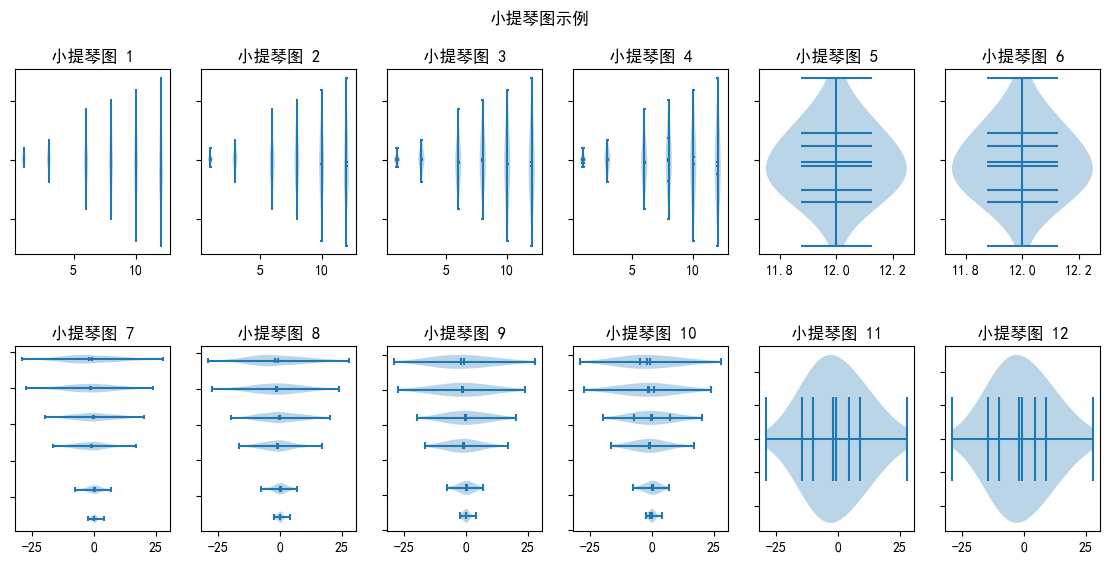

In [97]:
import matplotlib.pyplot as plt
import numpy as np

# 设置随机种子以确保结果可重复
np.random.seed(20240401)

# 生成模拟数据
font_size = 12  # 设置字体大小
positions = [1, 3, 6, 8, 10, 12]
data_sets = [np.random.normal(0, std_dev, size=150) for std_dev in positions]

fig, axs = plt.subplots(nrows=2, ncols=6, figsize=(14, 6))

# 自定义小提琴图 1
axs[0, 0].violinplot(data_sets, positions, points=25, widths=0.3,
                     showmeans=True, showextrema=True, showmedians=True)
axs[0, 0].set_title('小提琴图 1', fontsize=font_size)

# 自定义小提琴图 2
axs[0, 1].violinplot(data_sets, positions, points=50, widths=0.4,
                     showmeans=True, showextrema=True, showmedians=True,
                     bw_method='scott')
axs[0, 1].set_title('小提琴图 2', fontsize=font_size)

# 自定义小提琴图 3
axs[0, 2].violinplot(data_sets, positions, points=75, widths=0.5, showmeans=True,
                     showextrema=True, showmedians=True, bw_method=0.75)
axs[0, 2].set_title('小提琴图 3', fontsize=font_size)

# 自定义小提琴图 4
axs[0, 3].violinplot(data_sets, positions, points=75, widths=0.5, showmeans=True,
                     showextrema=True, showmedians=True, bw_method=0.75,
                     quantiles=[[0.2], [], [], [0.2, 0.8], [0.6], [0.4]])
axs[0, 3].set_title('小提琴图 4', fontsize=font_size)

# 自定义小提琴图 5（显示单个数据集）
axs[0, 4].violinplot(data_sets[-1:], positions[-1:], points=75, widths=0.5,
                     showmeans=True, showextrema=True, showmedians=True,
                     quantiles=[0.1, 0.2, 0.7, 0.8], bw_method=0.75)
axs[0, 4].set_title('小提琴图 5', fontsize=font_size)

# 自定义小提琴图 6
axs[0, 5].violinplot(data_sets[-1:], positions[-1:], points=75, widths=0.5,
                     showmeans=True, showextrema=True, showmedians=True,
                     quantiles=[0.1, 0.2, 0.7, 0.8], bw_method=0.75)
axs[0, 5].set_title('小提琴图 6', fontsize=font_size)

# 自定义小提琴图 7（横向显示）
axs[1, 0].violinplot(data_sets, positions, points=100, vert=False, widths=0.6,
                     showmeans=True, showextrema=True, showmedians=True)
axs[1, 0].set_title('小提琴图 7', fontsize=font_size)

# 自定义小提琴图 8（横向显示）
axs[1, 1].violinplot(data_sets, positions, points=150, vert=False, widths=0.8,
                     showmeans=True, showextrema=True, showmedians=True,
                     bw_method='scott')
axs[1, 1].set_title('小提琴图 8', fontsize=font_size)

# 自定义小提琴图 9（横向显示）
axs[1, 2].violinplot(data_sets, positions, points=150, vert=False, widths=1.0,
                     showmeans=True, showextrema=True, showmedians=True,
                     bw_method=0.75)
axs[1, 2].set_title('小提琴图 9', fontsize=font_size)

# 自定义小提琴图 10（带有不同分位数）
axs[1, 3].violinplot(data_sets, positions, points=150, vert=False, widths=1.0,
                     showmeans=True, showextrema=True, showmedians=True,
                     quantiles=[[0.2], [], [], [0.2, 0.8], [0.6], [0.4]],
                     bw_method=0.75)
axs[1, 3].set_title('小提琴图 10', fontsize=font_size)

# 自定义小提琴图 11（显示单个数据集，横向显示）
axs[1, 4].violinplot(data_sets[-1:], positions[-1:], points=150, vert=False, widths=1.0,
                     showmeans=True, showextrema=True, showmedians=True,
                     quantiles=[0.1, 0.2, 0.7, 0.8], bw_method=0.75)
axs[1, 4].set_title('小提琴图 11', fontsize=font_size)

# 自定义小提琴图 12（横向显示）
axs[1, 5].violinplot(data_sets[-1:], positions[-1:], points=150, vert=False, widths=1.0,
                     showmeans=True, showextrema=True, showmedians=True,
                     quantiles=[0.1, 0.2, 0.7, 0.8], bw_method=0.75)
axs[1, 5].set_title('小提琴图 12', fontsize=font_size)

# 设置每个子图的 y 轴标签为空
for ax in axs.flat:
    ax.set_yticklabels([])

# 添加整体标题并调整布局
fig.suptitle("小提琴图示例")
fig.subplots_adjust(hspace=0.5)
plt.show()


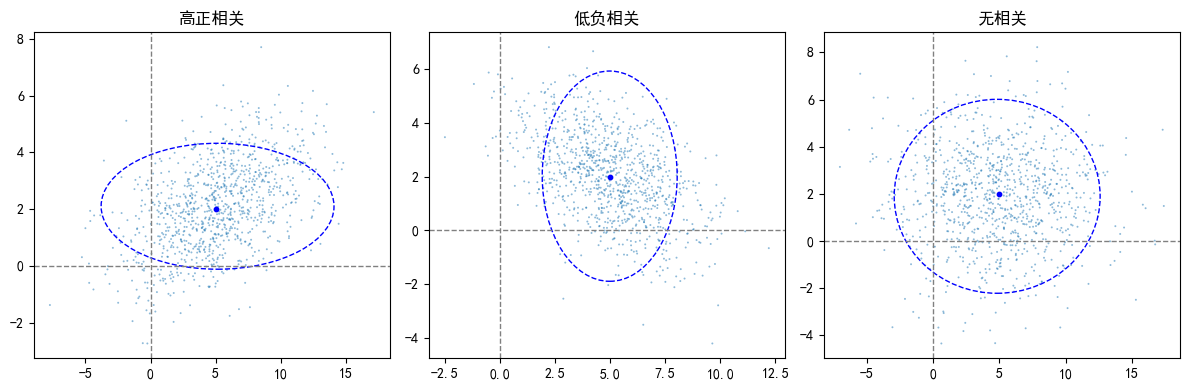

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib import transforms

def draw_confidence_ellipse(x, y, ax, n_std=2.0, facecolor='none', **kwargs):
    """
    绘制协方差置信椭圆

    参数
    ----------
    x, y : array-like, shape (n, )
        输入数据。

    ax : matplotlib.axes.Axes
        目标绘图区域。

    n_std : float
        确定椭圆半径的标准差倍数。

    **kwargs
        传递给 `~matplotlib.patches.Ellipse` 的参数。

    返回
    -------
    matplotlib.patches.Ellipse
    """
    if x.size != y.size:
        raise ValueError("x 和 y 的大小必须相同")

    cov = np.cov(x, y)
    pearson_corr = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson_corr)
    ell_radius_y = np.sqrt(1 - pearson_corr)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                      facecolor=facecolor, **kwargs)

    # 标准差乘以指定的倍数
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    transf = transforms.Affine2D() \
        .rotate_deg(0) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)

    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

def generate_correlated_data(n, matrix, offset, scale):
    """
    生成相关数据集

    参数
    ----------
    n : int
        数据点数量。

    matrix : array-like, shape (2, 2)
        相关系数矩阵。

    offset : tuple
        数据的偏移量。

    scale : tuple
        数据的缩放因子。

    返回
    -------
    tuple : (x, y)
        生成的相关数据。
    """
    random_latent = np.random.randn(n, 2)
    dependent_data = random_latent.dot(matrix)
    scaled_data = dependent_data * scale
    offset_data = scaled_data + offset
    return offset_data[:, 0], offset_data[:, 1]

np.random.seed(42)

# 定义相关系数矩阵
CORRELATION_MATRICES = {
    '高正相关': [[0.95, 0.3],
               [0.1, 0.7]],
    '低负相关': [[0.5, -0.6],
               [-0.2, -0.5]],
    '无相关': [[1, 0],
              [0, 1]],
}

offset = 5, 2
scale_factors = 4, 2

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (label, matrix) in zip(axes, CORRELATION_MATRICES.items()):
    x, y = generate_correlated_data(1000, matrix, offset, scale_factors)
    ax.scatter(x, y, s=2, alpha=0.5, edgecolor='none')

    ax.axvline(c='grey', lw=1, linestyle='--')
    ax.axhline(c='grey', lw=1, linestyle='--')

    draw_confidence_ellipse(x, y, ax, edgecolor='blue', linestyle='--')

    ax.scatter(offset[0], offset[1], c='blue', s=10)
    ax.set_title(label)

plt.tight_layout()
plt.show()


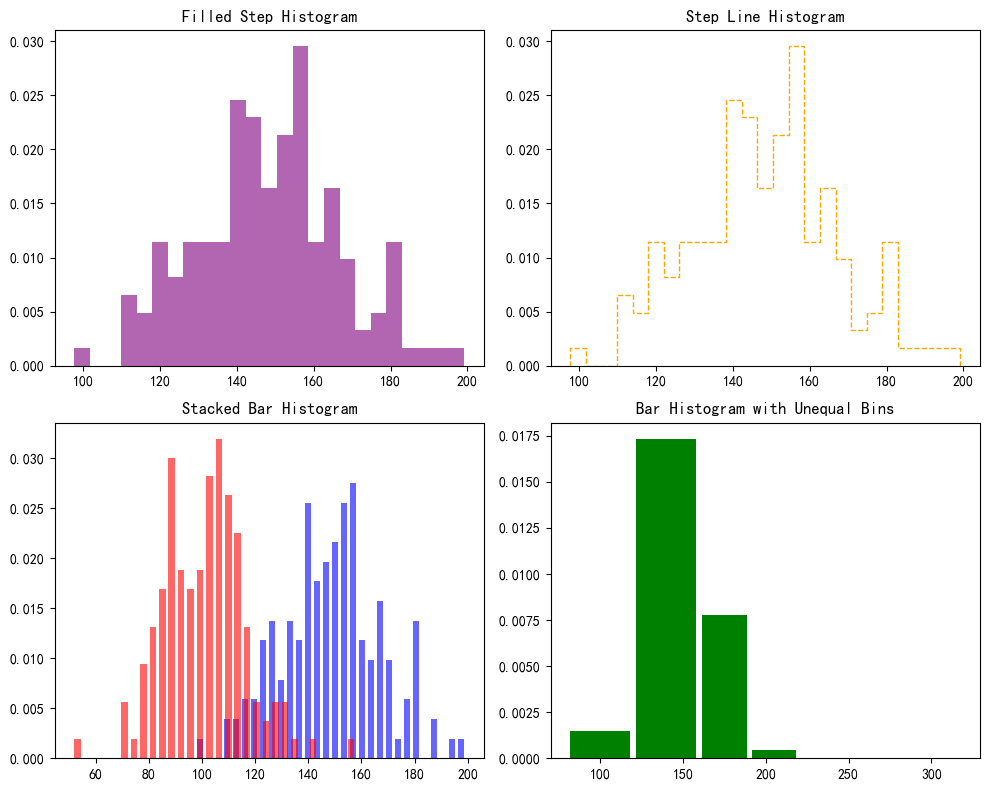

In [101]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)  # 更改随机种子以生成不同的数据

# 生成数据
mean_a = 150
std_a = 20
data_a = np.random.normal(mean_a, std_a, size=150)

mean_b = 100
std_b = 15
data_b = np.random.normal(mean_b, std_b, size=150)

# 创建图形和子图
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

# 绘制填充的步骤直方图
axes[0, 0].hist(data_a, bins=25, density=True, histtype='stepfilled', color='purple', alpha=0.6)
axes[0, 0].set_title('Filled Step Histogram')

# 绘制线条的步骤直方图
axes[0, 1].hist(data_a, bins=25, density=True, histtype='step', color='orange', linestyle='--')
axes[0, 1].set_title('Step Line Histogram')

# 绘制堆叠条形图
axes[1, 0].hist(data_a, bins=30, density=True, histtype='barstacked', color='blue', alpha=0.6, rwidth=0.7)
axes[1, 0].hist(data_b, bins=30, density=True, histtype='barstacked', color='red', alpha=0.6, rwidth=0.7)
axes[1, 0].set_title('Stacked Bar Histogram')

# 绘制不均匀间隔的条形图
bins = [80, 120, 160, 190, 220, 270, 320]  # 不均匀间隔的箱子
axes[1, 1].hist(data_a, bins=bins, density=True, histtype='bar', color='green', rwidth=0.9)
axes[1, 1].set_title('Bar Histogram with Unequal Bins')

# 调整图形布局
fig.tight_layout()
plt.show()
